In [1]:
from rfdetr import RFDETRBase

# suppress warnings
import warnings
warnings.filterwarnings("ignore")

/home/arina_belova_jetbrains_com/three_od_models/rf-detr/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/arina_belova_jetbrains_com/three_od_models/rf-detr/.venv/lib/python3.11/site-packages/rfdetr/models/weights.py:258: FutureWarning: target=True is deprecated since `v0.8`; use `TargetMode.ARGS_REMAP` instead. Will be removed in `v1.0`.
  @deprecated(target=True, args_mapping={"train_config": None}, deprecated_in="1.7.0", remove_in="1.9.0", num_warns=-1)


In [3]:
model = RFDETRBase()

[2026-07-02 09:47:34] [INFO] rf-detr - File /home/arina_belova_jetbrains_com/.roboflow/models/rf-detr-base.pth already exists with correct MD5 hash.
[2026-07-02 09:47:36] [INFO] rf-detr - File /home/arina_belova_jetbrains_com/.roboflow/models/rf-detr-base.pth already exists with correct MD5 hash.


[2026-07-02 09:47:38] [WARNING] rf-detr - Pretrained weights at '/home/arina_belova_jetbrains_com/.roboflow/models/rf-detr-base.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.


In [3]:
model.optimize_for_inference()
detections = model.predict("/home/arina_belova_jetbrains_com/doggo.jpeg")

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
/home/arina_belova_jetbrains_com/three_od_models/rf-detr/.venv/lib/python3.11/site-packages/rfdetr/models/backbone/dinov2.py:212: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert x.shape[2] % block_size == 0 and x.shape[3] % block_size == 0, (
/home/arina_belova_jetbrains_com/three_od_models/rf-detr/.venv/lib/python3.11/site-packages/rfdetr/models/backbone/dinov2_with_windowed_attn.py:410: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inpu

In [5]:
detections

Detections(xyxy=array([[ 453.6397  ,   37.502586, 1118.8519  ,  891.3945  ]],
      dtype=float32), mask=None, confidence=array([0.9611071], dtype=float32), class_id=array([18]), tracker_id=None, data={'source_shape': array([[ 901, 1603]]), 'class_name': array(['dog'], dtype=object)}, metadata={'source_image': array([[[166, 165, 145],
        [182, 181, 161],
        [175, 173, 152],
        ...,
        [ 36,  30,   8],
        [ 39,  34,  15],
        [  4,   0,   0]],

       [[240, 239, 219],
        [250, 249, 229],
        [242, 240, 219],
        ...,
        [ 35,  29,   7],
        [ 38,  33,  14],
        [  4,   0,   0]],

       [[234, 233, 212],
        [249, 248, 227],
        [255, 255, 235],
        ...,
        [ 34,  28,   6],
        [ 37,  32,  13],
        [  4,   0,   0]],

       ...,

       [[ 55,  53,  41],
        [ 33,  31,  19],
        [ 24,  21,  12],
        ...,
        [ 59,  53,  39],
        [ 48,  44,  33],
        [  4,   0,   0]],

       [[ 47,  

In [6]:
from transformers import pipeline
pipe = pipeline("object-detection", model="Roboflow/rf-detr-base")

Loading weights: 100%|██████████| 487/487 [00:00<00:00, 3524.54it/s]


In [15]:
# Pass a local path, a URL, or a PIL.Image
# print("We retreived model: ", pipe.model)
results = pipe("/home/arina_belova_jetbrains_com/doggo.jpeg")

for r in results:
    print(r)

{'score': 0.9615841507911682, 'label': 'dog', 'box': {'xmin': 453, 'ymin': 37, 'xmax': 1118, 'ymax': 891}}


In [25]:
import time
import statistics
from pathlib import Path
from typing import List, Optional, Union
import colorsys

import requests
import torch
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt


IMG_EXTS = {".jpg", ".jpeg"}


# ---------- I/O & drawing helpers (unchanged) ----------

def collect_images(folder, recursive=False):
    folder = Path(folder)
    if not folder.is_dir():
        raise NotADirectoryError(f"{folder} is not a directory.")
    it = folder.rglob("*") if recursive else folder.iterdir()
    files = sorted(p for p in it if p.is_file() and p.suffix.lower() in IMG_EXTS)
    if not files:
        raise FileNotFoundError(f"No images found in {folder}.")
    return files


def _load_image(img):
    if isinstance(img, Image.Image):
        return img.convert("RGB")
    s = str(img)
    if s.startswith(("http://", "https://")):
        return Image.open(requests.get(s, stream=True).raw).convert("RGB")
    return Image.open(s).convert("RGB")


def _color_for_label(label):
    h = (hash(label) % 360) / 360.0
    r, g, b = colorsys.hsv_to_rgb(h, 0.85, 0.95)
    return int(r * 255), int(g * 255), int(b * 255)


def _get_font(size):
    for candidate in ("DejaVuSans-Bold.ttf", "Arial.ttf"):
        try:
            return ImageFont.truetype(candidate, size=size)
        except OSError:
            continue
    return ImageFont.load_default()


def _draw_detections(image, detections, threshold=0.0, line_width=3, font_size=None):
    out = image.copy()
    draw = ImageDraw.Draw(out)
    if font_size is None:
        font_size = max(14, int(min(out.size) * 0.025))
    font = _get_font(font_size)
    for det in detections:
        score = float(det["score"])
        if score < threshold:
            continue
        label = det["label"]
        box = det["box"]
        x1, y1, x2, y2 = box["xmin"], box["ymin"], box["xmax"], box["ymax"]
        color = _color_for_label(label)
        draw.rectangle([(x1, y1), (x2, y2)], outline=color, width=line_width)
        text = f"{label} {score:.2f}"
        try:
            tx1, ty1, tx2, ty2 = draw.textbbox((0, 0), text, font=font)
            tw, th = tx2 - tx1, ty2 - ty1
        except AttributeError:
            tw, th = draw.textsize(text, font=font)
        pad = 2
        bg_y1 = max(0, y1 - th - 2 * pad)
        draw.rectangle([(x1, bg_y1), (x1 + tw + 2 * pad, bg_y1 + th + 2 * pad)], fill=color)
        draw.text((x1 + pad, bg_y1 + pad), text, fill="white", font=font)
    return out


# ---------- Timing helpers ----------

def _sync_if_cuda(device):
    """Synchronize CUDA so wall-clock timing is meaningful."""
    if isinstance(device, torch.device) and device.type == "cuda":
        torch.cuda.synchronize(device)
    elif isinstance(device, str) and device.startswith("cuda"):
        torch.cuda.synchronize()


def _now():
    return time.perf_counter()


# ---------- Main function ----------

def detect_and_visualize_folder(
    pipe,
    folder: Union[str, Path],
    threshold: float = 0.5,
    batch_size: int = 4,
    recursive: bool = False,
    line_width: int = 3,
    font_size: Optional[int] = None,
    show: bool = True,
    save_dir: Optional[Union[str, Path]] = None,
    cols: int = 3,
    figsize_per_image: tuple = (6, 6),
    max_show: Optional[int] = 12,
    warmup: bool = True,
    verbose: bool = True,
):
    """
    Run an HF object-detection pipeline on a folder of images, visualize results,
    and report inference timings.

    Returns:
        dict with keys:
          - "results":  list of {"path", "image", "detections", "time_s"}
          - "timings":  dict of aggregate timing statistics (seconds & FPS)
    """
    paths = collect_images(folder, recursive=recursive)
    if verbose:
        print(f"Found {len(paths)} image(s) in {folder}")

    pil_images = [_load_image(p) for p in paths]
    device = getattr(pipe.model, "device", torch.device("cpu"))

    # ---- Warm-up (excluded from stats) ----
    if warmup and len(pil_images) > 0:
        if verbose:
            print(f"Warming up on device={device} ...")
        _ = pipe(pil_images[0], threshold=threshold)
        _sync_if_cuda(device)

    # ---- Timed inference, batch by batch ----
    all_detections: List[List[dict]] = []
    per_batch_times: List[float] = []   # seconds per batch
    per_image_times: List[float] = []   # seconds per image (batch_time / batch_size)
    batch_sizes: List[int] = []

    total_start = _now()
    for i in range(0, len(pil_images), batch_size):
        batch = pil_images[i : i + batch_size]

        _sync_if_cuda(device)
        t0 = _now()
        batch_results = pipe(batch, threshold=threshold, batch_size=len(batch))
        _sync_if_cuda(device)
        dt = _now() - t0

        if batch_results and isinstance(batch_results[0], dict):
            batch_results = [batch_results]

        all_detections.extend(batch_results)
        per_batch_times.append(dt)
        batch_sizes.append(len(batch))
        per_image_times.extend([dt / len(batch)] * len(batch))

        if verbose:
            print(
                f"  batch {len(per_batch_times):>3} | "
                f"size={len(batch)} | "
                f"{dt * 1000:7.1f} ms total | "
                f"{(dt / len(batch)) * 1000:6.1f} ms/img | "
                f"{len(batch) / dt:6.2f} FPS"
            )
    total_elapsed = _now() - total_start

    # ---- Aggregate stats ----
    n = len(pil_images)
    timings = {
        "device": str(device),
        "num_images": n,
        "num_batches": len(per_batch_times),
        "batch_size": batch_size,
        "total_elapsed_s": total_elapsed,
        "total_throughput_fps": n / total_elapsed if total_elapsed > 0 else float("inf"),
        "mean_per_image_ms": 1000 * statistics.mean(per_image_times),
        "median_per_image_ms": 1000 * statistics.median(per_image_times),
        "min_per_image_ms": 1000 * min(per_image_times),
        "max_per_image_ms": 1000 * max(per_image_times),
        "stdev_per_image_ms": 1000 * statistics.pstdev(per_image_times) if len(per_image_times) > 1 else 0.0,
    }

    if verbose:
        print("\n--- Inference timing summary ---")
        print(f"  device              : {timings['device']}")
        print(f"  images              : {timings['num_images']}")
        print(f"  batches             : {timings['num_batches']} (batch_size={batch_size})")
        print(f"  total time          : {timings['total_elapsed_s']:.3f} s")
        print(f"  throughput          : {timings['total_throughput_fps']:.2f} FPS")
        print(f"  mean   per image    : {timings['mean_per_image_ms']:.2f} ms")
        print(f"  median per image    : {timings['median_per_image_ms']:.2f} ms")
        print(f"  min / max per image : {timings['min_per_image_ms']:.2f} / {timings['max_per_image_ms']:.2f} ms")
        print(f"  stdev               : {timings['stdev_per_image_ms']:.2f} ms")
        print("--------------------------------\n")

    # ---- Annotate ----
    annotated = [
        _draw_detections(img, dets, threshold=threshold,
                         line_width=line_width, font_size=font_size)
        for img, dets in zip(pil_images, all_detections)
    ]

    # ---- Save ----
    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        for p, im in zip(paths, annotated):
            im.save(save_dir / f"{p.stem}_pred.png")
        if verbose:
            print(f"Saved annotated images to {save_dir}")

    # ---- Show ----
    if show and annotated:
        to_show = annotated if max_show is None else annotated[:max_show]
        shown_paths = paths if max_show is None else paths[:max_show]
        shown_times = per_image_times if max_show is None else per_image_times[:max_show]
        n_show = len(to_show)
        cols = max(1, min(cols, n_show))
        rows = (n_show + cols - 1) // cols
        fig, axes = plt.subplots(
            rows, cols,
            figsize=(figsize_per_image[0] * cols, figsize_per_image[1] * rows),
        )
        axes = [axes] if n_show == 1 else (axes.flatten() if hasattr(axes, "flatten") else list(axes))
        for ax, im, p, t in zip(axes, to_show, shown_paths, shown_times):
            ax.imshow(im)
            ax.set_title(f"{p.name}\n{t * 1000:.1f} ms", fontsize=10)
            ax.axis("off")
        for ax in axes[n_show:]:
            ax.axis("off")
        plt.tight_layout()
        plt.show()
        if max_show is not None and len(annotated) > max_show:
            print(f"(Showing first {max_show} of {len(annotated)} images.)")

    results = [
        {"path": p, "image": im, "detections": dets, "time_s": t}
        for p, im, dets, t in zip(paths, annotated, all_detections, per_image_times)
    ]
    return {"results": results, "timings": timings}

Loading weights: 100%|██████████| 487/487 [00:00<00:00, 3231.03it/s]


Found 479 image(s) in /home/arina_belova_jetbrains_com/roboflow-100-benchmark/rf100/abdomen-mri/valid/images
Warming up on device=cuda:0 ...
  batch   1 | size=1 |    36.2 ms total |   36.2 ms/img |  27.60 FPS
  batch   2 | size=1 |    34.4 ms total |   34.4 ms/img |  29.07 FPS
  batch   3 | size=1 |    33.7 ms total |   33.7 ms/img |  29.63 FPS
  batch   4 | size=1 |    33.8 ms total |   33.8 ms/img |  29.57 FPS
  batch   5 | size=1 |    33.8 ms total |   33.8 ms/img |  29.59 FPS
  batch   6 | size=1 |    33.7 ms total |   33.7 ms/img |  29.69 FPS
  batch   7 | size=1 |    33.4 ms total |   33.4 ms/img |  29.90 FPS
  batch   8 | size=1 |    33.2 ms total |   33.2 ms/img |  30.10 FPS
  batch   9 | size=1 |    33.6 ms total |   33.6 ms/img |  29.80 FPS
  batch  10 | size=1 |    33.0 ms total |   33.0 ms/img |  30.31 FPS
  batch  11 | size=1 |    34.3 ms total |   34.3 ms/img |  29.18 FPS
  batch  12 | size=1 |    33.3 ms total |   33.3 ms/img |  30.00 FPS
  batch  13 | size=1 |    32.8 

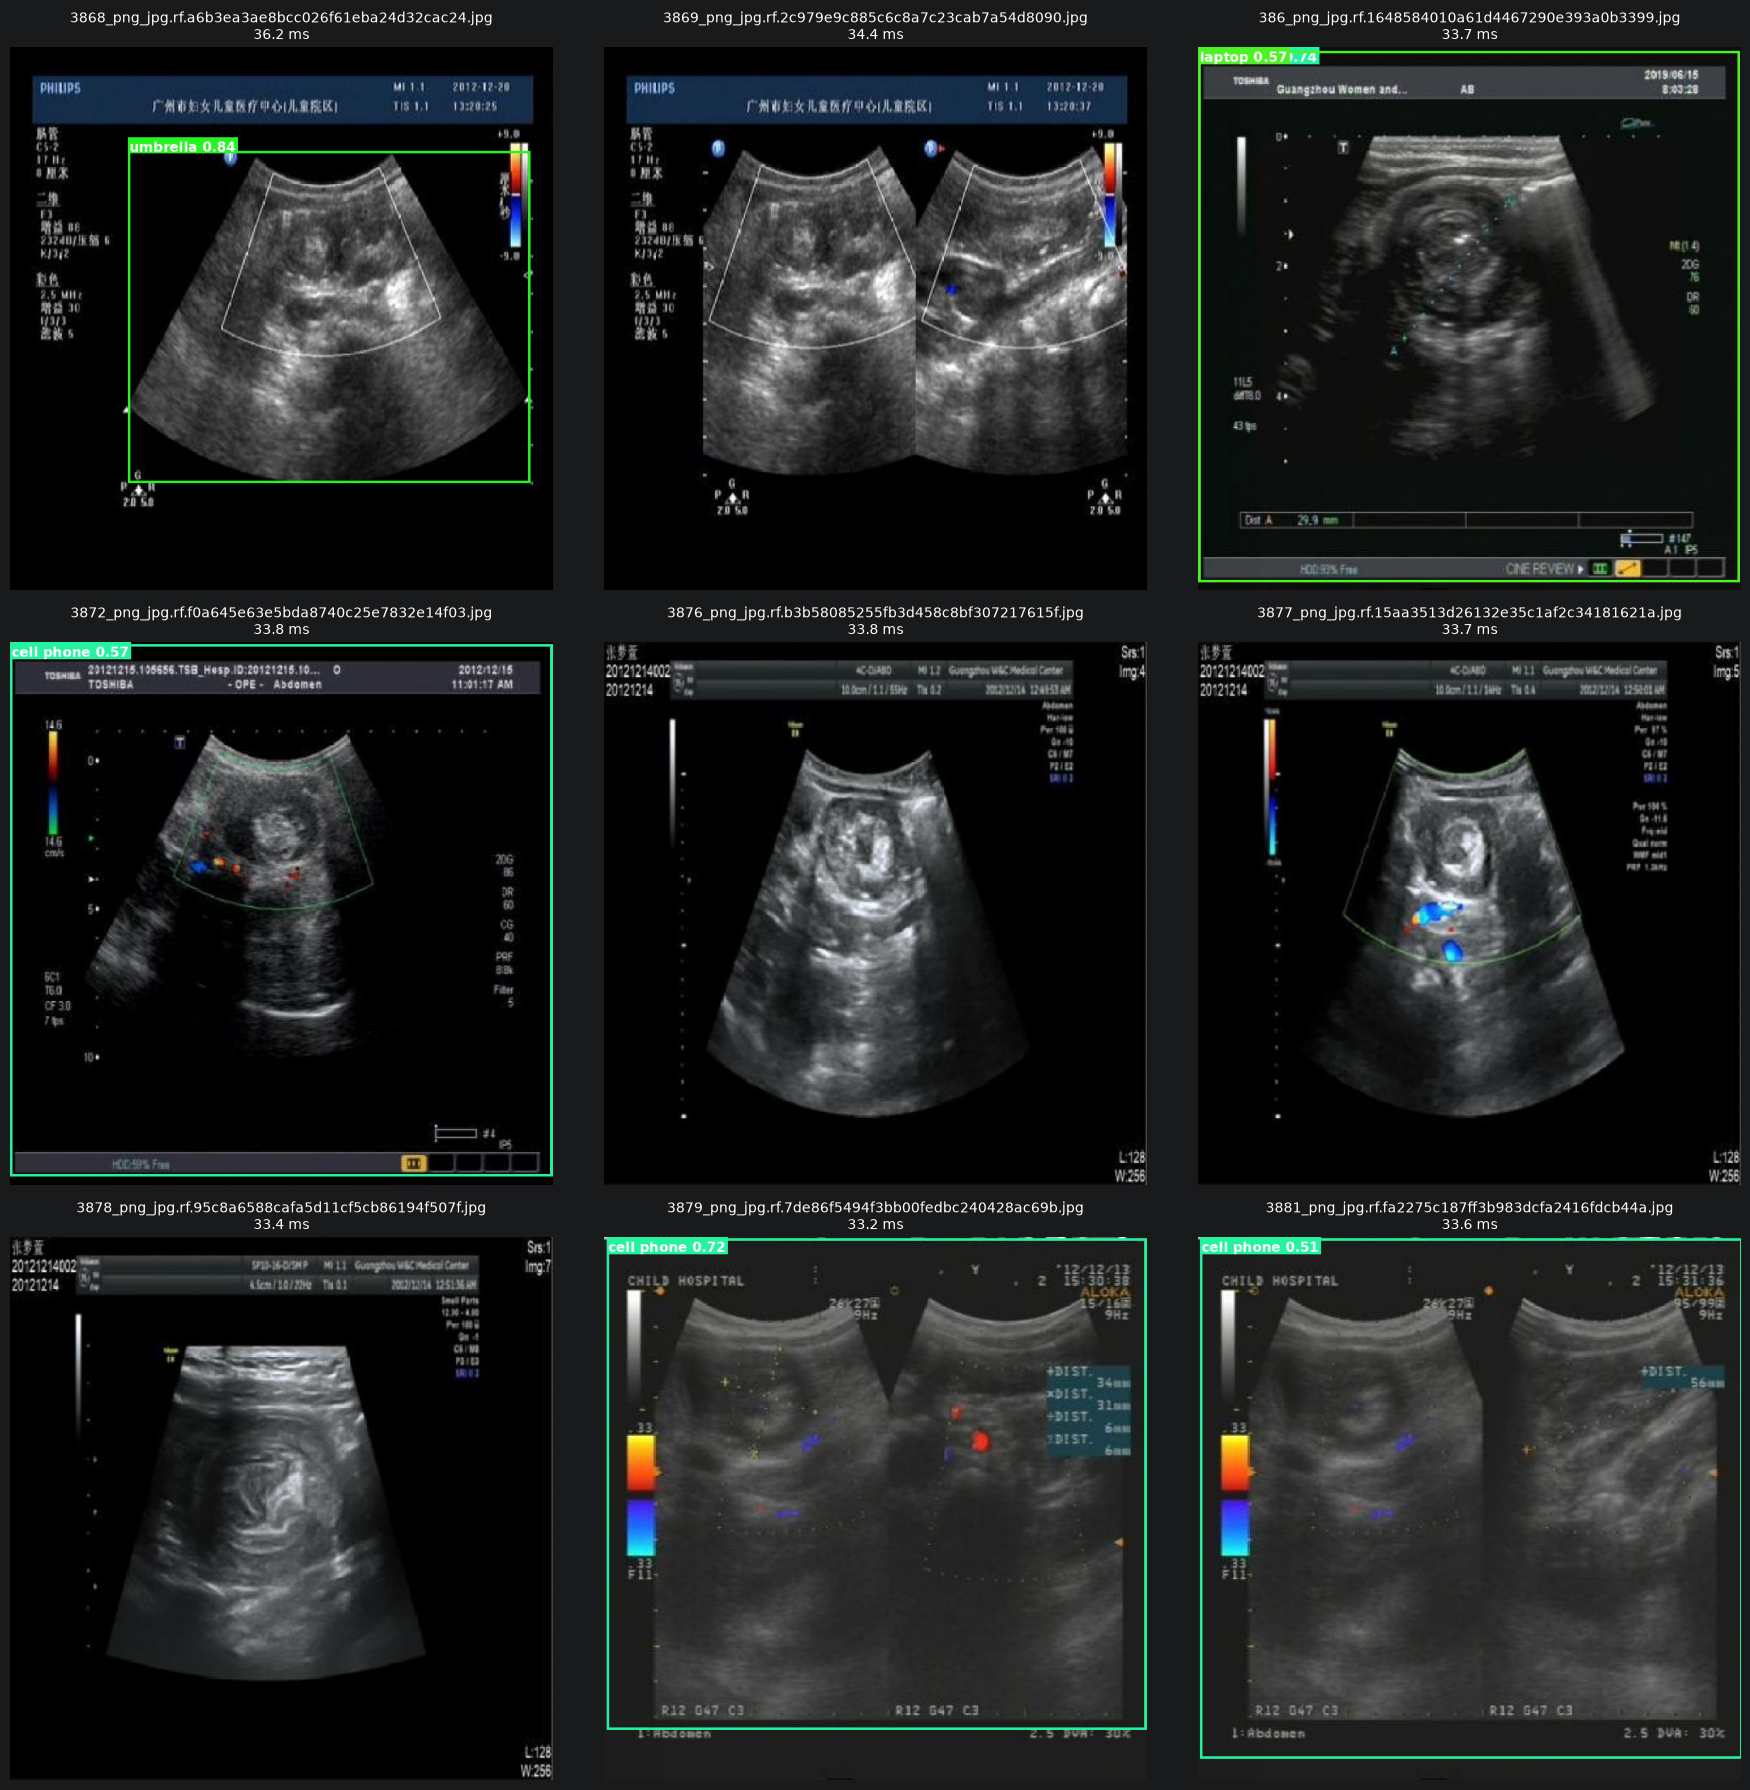

(Showing first 9 of 479 images.)
{'device': 'cuda:0', 'num_images': 479, 'num_batches': 479, 'batch_size': 1, 'total_elapsed_s': 21.414764049928635, 'total_throughput_fps': 22.367745863704545, 'mean_per_image_ms': 44.55263779395589, 'median_per_image_ms': 32.56540186703205, 'min_per_image_ms': 29.431811068207026, 'max_per_image_ms': 187.0286837220192, 'stdev_per_image_ms': 29.716339307736398}
3868_png_jpg.rf.a6b3ea3ae8bcc026f61eba24d32cac24.jpg: 36.2 ms
3869_png_jpg.rf.2c979e9c885c6c8a7c23cab7a54d8090.jpg: 34.4 ms
386_png_jpg.rf.1648584010a61d4467290e393a0b3399.jpg: 33.7 ms
3872_png_jpg.rf.f0a645e63e5bda8740c25e7832e14f03.jpg: 33.8 ms
3876_png_jpg.rf.b3b58085255fb3d458c8bf307217615f.jpg: 33.8 ms


In [29]:
from transformers import pipeline

pipe = pipeline("object-detection", model="Roboflow/rf-detr-base")
dataset_name = "abdomen-mri" #"4-fold-defect"
out = detect_and_visualize_folder(
    pipe,
    folder=f"/home/arina_belova_jetbrains_com/roboflow-100-benchmark/rf100/{dataset_name}/valid/images",
    threshold=0.5,
    batch_size=1,
    save_dir="./annotated_outputs",
    max_show=9,
)

print(out["timings"])
# Example: per-image timings
for r in out["results"][:5]:
    print(f"{r['path'].name}: {r['time_s'] * 1000:.1f} ms")

## Fine-tune RF-DETR on RF100 datasets

RF100 is stored locally in YOLO format, while RF-DETR training expects COCO JSON folders. These cells support three modes:

- `single`: train one model on `SINGLE_DATASET_NAME`.
- `separate`: train one independent model per dataset in `RF100_DATASETS`, matching the YOLO12 benchmark style.
- `combined`: merge several RF100 datasets into one COCO dataset and train one shared model.

In [3]:
from pathlib import Path

RF100_ROOT = Path("/home/arina_belova_jetbrains_com/roboflow-100-benchmark/rf100")
COCO_WORKDIR = Path("./rf100_coco")
TRAIN_OUTPUT_ROOT = Path("./rf100_rfdetr_runs")

# Choose one of: "single", "separate", "combined".
# "separate" trains one RF-DETR model per dataset, like the YOLO12 benchmark setup.
TRAIN_MODE = "separate"
SINGLE_DATASET_NAME = "cable-damage"

# Used by TRAIN_MODE="separate" and TRAIN_MODE="combined".
# Add or remove dataset folder names from RF100_ROOT as needed.
RF100_DATASETS = [
    "cable-damage",
    "bone-fracture-7fylg",
    "soda-bottles",
]

TRAIN_CONFIG = {
    "epochs": 10,
    "batch_size": 4,
    "grad_accum_steps": 4,
    "lr": 1e-4,
    "resolution": 560,  # RF-DETR requires this to be divisible by 56.
    "early_stopping": True,
    "checkpoint_interval": 1,
}

available_datasets = sorted(p.name for p in RF100_ROOT.iterdir() if p.is_dir())
print(f"Found {len(available_datasets)} RF100 dataset directories.")
print(f"TRAIN_MODE={TRAIN_MODE}")
print(f"SINGLE_DATASET_NAME={SINGLE_DATASET_NAME}")
print("RF100_DATASETS=", RF100_DATASETS)

Found 100 RF100 dataset directories.
TRAIN_MODE=separate
SINGLE_DATASET_NAME=cable-damage
RF100_DATASETS= ['cable-damage', 'bone-fracture-7fylg', 'soda-bottles']


In [5]:
import json
import shutil
from PIL import Image

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
SPLITS = ("train", "valid", "test")


def read_yolo_names(data_yaml_path: Path) -> list[str]:
    """Read the `names` list from a small Roboflow YOLO data.yaml without requiring PyYAML."""
    lines = data_yaml_path.read_text().splitlines()
    names = []
    in_names = False
    for line in lines:
        stripped = line.strip()
        if stripped.startswith("names:"):
            in_names = True
            after = stripped.split(":", 1)[1].strip()
            if after.startswith("[") and after.endswith("]"):
                return [x.strip().strip("'\"") for x in after[1:-1].split(",") if x.strip()]
            continue
        if in_names:
            if stripped.startswith("-"):
                names.append(stripped[1:].strip().strip("'\""))
            elif stripped and not line.startswith(" "):
                break
    if not names:
        raise ValueError(f"Could not parse class names from {data_yaml_path}")
    return names


def yolo_split_to_coco(dataset_dir: Path, split: str, out_split_dir: Path, categories: list[dict]) -> dict:
    image_dir = dataset_dir / split / "images"
    label_dir = dataset_dir / split / "labels"
    out_split_dir.mkdir(parents=True, exist_ok=True)

    images = []
    annotations = []
    ann_id = 1
    image_id = 1

    for image_path in sorted(p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS):
        target_image_path = out_split_dir / image_path.name
        if not target_image_path.exists():
            shutil.copy2(image_path, target_image_path)

        with Image.open(image_path) as image:
            width, height = image.size

        images.append({
            "id": image_id,
            "file_name": image_path.name,
            "width": width,
            "height": height,
        })

        label_path = label_dir / f"{image_path.stem}.txt"
        if label_path.exists():
            for raw_line in label_path.read_text().splitlines():
                parts = raw_line.strip().split()
                if len(parts) < 5:
                    continue
                class_idx = int(float(parts[0]))
                x_center, y_center, box_w, box_h = map(float, parts[1:5])

                abs_w = box_w * width
                abs_h = box_h * height
                x_min = (x_center * width) - (abs_w / 2)
                y_min = (y_center * height) - (abs_h / 2)

                x_min = max(0.0, min(x_min, float(width)))
                y_min = max(0.0, min(y_min, float(height)))
                abs_w = max(0.0, min(abs_w, float(width) - x_min))
                abs_h = max(0.0, min(abs_h, float(height) - y_min))

                if abs_w <= 0 or abs_h <= 0:
                    continue

                annotations.append({
                    "id": ann_id,
                    "image_id": image_id,
                    "category_id": class_idx + 1,
                    "bbox": [x_min, y_min, abs_w, abs_h],
                    "area": abs_w * abs_h,
                    "iscrowd": 0,
                    "segmentation": [],
                })
                ann_id += 1

        image_id += 1

    coco = {
        "info": {"description": f"{dataset_dir.name} {split} converted from RF100 YOLO"},
        "licenses": [],
        "categories": categories,
        "images": images,
        "annotations": annotations,
    }
    (out_split_dir / "_annotations.coco.json").write_text(json.dumps(coco))
    return {"images": len(images), "annotations": len(annotations)}


def convert_rf100_dataset_to_coco(dataset_name: str, force: bool = False) -> Path:
    dataset_dir = RF100_ROOT / dataset_name
    if not dataset_dir.exists():
        raise FileNotFoundError(f"Missing RF100 dataset: {dataset_dir}")

    out_dir = COCO_WORKDIR / dataset_name
    done_marker = out_dir / ".conversion_complete"
    if done_marker.exists() and not force:
        return out_dir

    if force and out_dir.exists():
        shutil.rmtree(out_dir)

    class_names = read_yolo_names(dataset_dir / "data.yaml")
    categories = [{"id": i + 1, "name": name, "supercategory": "object"} for i, name in enumerate(class_names)]

    summary = {}
    for split in SPLITS:
        split_dir = dataset_dir / split
        if not split_dir.exists():
            print(f"Skipping missing split: {dataset_name}/{split}")
            continue
        summary[split] = yolo_split_to_coco(dataset_dir, split, out_dir / split, categories)

    done_marker.write_text(json.dumps(summary, indent=2))
    print(f"Converted {dataset_name} -> {out_dir}")
    print(json.dumps(summary, indent=2))
    return out_dir


def merge_coco_datasets(dataset_names: list[str], merged_name: str | None = None, force: bool = False) -> Path:
    """Merge converted RF100 COCO datasets into one COCO dataset with dataset-prefixed class names."""
    merged_name = merged_name or "combined__" + "__".join(dataset_names)
    out_dir = COCO_WORKDIR / merged_name
    done_marker = out_dir / ".merge_complete"
    if done_marker.exists() and not force:
        return out_dir

    if out_dir.exists():
        shutil.rmtree(out_dir)

    converted_dirs = {name: convert_rf100_dataset_to_coco(name) for name in dataset_names}
    summary = {}

    for split in SPLITS:
        out_split_dir = out_dir / split
        out_split_dir.mkdir(parents=True, exist_ok=True)

        merged_images = []
        merged_annotations = []
        merged_categories = []
        next_image_id = 1
        next_annotation_id = 1
        next_category_id = 1

        for dataset_name, dataset_dir in converted_dirs.items():
            annotation_path = dataset_dir / split / "_annotations.coco.json"
            if not annotation_path.exists():
                continue

            coco = json.loads(annotation_path.read_text())
            category_id_map = {}
            for category in coco["categories"]:
                category_id_map[category["id"]] = next_category_id
                merged_categories.append({
                    "id": next_category_id,
                    "name": f"{dataset_name}/{category['name']}",
                    "supercategory": category.get("supercategory", "object"),
                })
                next_category_id += 1

            image_id_map = {}
            for image in coco["images"]:
                new_file_name = f"{dataset_name}__{image['file_name']}"
                shutil.copy2(dataset_dir / split / image["file_name"], out_split_dir / new_file_name)
                image_id_map[image["id"]] = next_image_id
                merged_images.append({
                    **image,
                    "id": next_image_id,
                    "file_name": new_file_name,
                })
                next_image_id += 1

            for annotation in coco["annotations"]:
                merged_annotations.append({
                    **annotation,
                    "id": next_annotation_id,
                    "image_id": image_id_map[annotation["image_id"]],
                    "category_id": category_id_map[annotation["category_id"]],
                })
                next_annotation_id += 1

        merged_coco = {
            "info": {"description": f"Merged RF100 datasets: {', '.join(dataset_names)}"},
            "licenses": [],
            "categories": merged_categories,
            "images": merged_images,
            "annotations": merged_annotations,
        }
        (out_split_dir / "_annotations.coco.json").write_text(json.dumps(merged_coco))
        summary[split] = {
            "images": len(merged_images),
            "annotations": len(merged_annotations),
            "categories": len(merged_categories),
        }

    done_marker.write_text(json.dumps(summary, indent=2))
    print(f"Merged {dataset_names} -> {out_dir}")
    print(json.dumps(summary, indent=2))
    return out_dir


if TRAIN_MODE == "single":
    DATASET_DIRS_FOR_TRAINING = {SINGLE_DATASET_NAME: convert_rf100_dataset_to_coco(SINGLE_DATASET_NAME)}
elif TRAIN_MODE == "separate":
    DATASET_DIRS_FOR_TRAINING = {name: convert_rf100_dataset_to_coco(name) for name in RF100_DATASETS}
elif TRAIN_MODE == "combined":
    combined_name = "combined__" + "__".join(RF100_DATASETS)
    DATASET_DIRS_FOR_TRAINING = {combined_name: merge_coco_datasets(RF100_DATASETS, merged_name=combined_name)}
else:
    raise ValueError(f"Unknown TRAIN_MODE: {TRAIN_MODE!r}")

DATASET_DIRS_FOR_TRAINING

{'cable-damage': PosixPath('rf100_coco/cable-damage'),
 'bone-fracture-7fylg': PosixPath('rf100_coco/bone-fracture-7fylg'),
 'soda-bottles': PosixPath('rf100_coco/soda-bottles')}

In [6]:
from rfdetr import RFDETRBase


def fine_tune_rfdetr(dataset_key: str, dataset_dir: Path, train_config: dict = TRAIN_CONFIG):
    output_dir = TRAIN_OUTPUT_ROOT / TRAIN_MODE / dataset_key
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n=== Fine-tuning RF-DETR: mode={TRAIN_MODE}, dataset={dataset_key} ===")
    print(f"dataset_dir={dataset_dir}")
    print(f"output_dir={output_dir}")

    model = RFDETRBase()
    model.train(
        dataset_dir=str(dataset_dir),
        output_dir=str(output_dir),
        **train_config,
    )
    return {
        "mode": TRAIN_MODE,
        "dataset": dataset_key,
        "dataset_dir": dataset_dir,
        "output_dir": output_dir,
        "best_checkpoint": output_dir / "checkpoint_best_total.pth",
    }


training_runs = []
for dataset_key, dataset_dir in DATASET_DIRS_FOR_TRAINING.items():
    training_runs.append(fine_tune_rfdetr(dataset_key, dataset_dir))

training_runs


=== Fine-tuning RF-DETR: mode=separate, dataset=cable-damage ===
dataset_dir=rf100_coco/cable-damage
output_dir=rf100_rfdetr_runs/separate/cable-damage


/tmp/ipykernel_2685771/3679416506.py:12: FutureWarning: The `RFDETRBase` was deprecated since v1.7.0. It will be removed in v2.0.0.
  model = RFDETRBase()


[2026-07-02 11:33:14] [INFO] rf-detr - File /home/arina_belova_jetbrains_com/.roboflow/models/rf-detr-base.pth already exists with correct MD5 hash.
[2026-07-02 11:33:16] [INFO] rf-detr - File /home/arina_belova_jetbrains_com/.roboflow/models/rf-detr-base.pth already exists with correct MD5 hash.


[2026-07-02 11:33:18] [WARNING] rf-detr - Pretrained weights at '/home/arina_belova_jetbrains_com/.roboflow/models/rf-detr-base.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.


[2026-07-02 11:33:23] [INFO] rf-detr - File /home/arina_belova_jetbrains_com/.roboflow/models/rf-detr-base.pth already exists with correct MD5 hash.


...

Metric __rfdetr_effective_map__ improved by 0.002 >= min_delta = 0.001. New best score: 0.549


[2026-07-02 12:56:21] [INFO] rf-detr - Best EMA mAP improved to 0.5492 (epoch 9)


`Trainer.fit` stopped: `max_epochs=10` reached.


[2026-07-02 12:56:25] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.5441, ema=0.5492)


[{'mode': 'separate',
  'dataset': 'cable-damage',
  'dataset_dir': PosixPath('rf100_coco/cable-damage'),
  'output_dir': PosixPath('rf100_rfdetr_runs/separate/cable-damage'),
  'best_checkpoint': PosixPath('rf100_rfdetr_runs/separate/cable-damage/checkpoint_best_total.pth')},
 {'mode': 'separate',
  'dataset': 'bone-fracture-7fylg',
  'dataset_dir': PosixPath('rf100_coco/bone-fracture-7fylg'),
  'output_dir': PosixPath('rf100_rfdetr_runs/separate/bone-fracture-7fylg'),
  'best_checkpoint': PosixPath('rf100_rfdetr_runs/separate/bone-fracture-7fylg/checkpoint_best_total.pth')},
 {'mode': 'separate',
  'dataset': 'soda-bottles',
  'dataset_dir': PosixPath('rf100_coco/soda-bottles'),
  'output_dir': PosixPath('rf100_rfdetr_runs/separate/soda-bottles'),
  'best_checkpoint': PosixPath('rf100_rfdetr_runs/separate/soda-bottles/checkpoint_best_total.pth')}]

In [7]:
# Load a fine-tuned checkpoint for inference after training.
# For TRAIN_MODE="separate", change the index to inspect another dataset run.
run = training_runs[0]
checkpoint_path = run["best_checkpoint"]

fine_tuned_model = RFDETRBase(pretrain_weights=str(checkpoint_path))
print(f"Loaded {checkpoint_path}")

[2026-07-02 12:56:26] [WARNING] rf-detr - Checkpoint has 2 classes but model is configured for 90. Using checkpoint class count (2). Pass num_classes=2 to suppress this warning.
[2026-07-02 12:56:26] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


Loaded rf100_rfdetr_runs/separate/cable-damage/checkpoint_best_total.pth


## Post-hoc RF-DETR training plots

RF-DETR uses PyTorch Lightning internally and writes `{output_dir}/metrics.csv` for every training run. These cells read those CSVs after training and plot AP50:95, AP50, losses, and other validation statistics.

In [15]:
import csv
import math
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

AP50_95_METRIC = "val/mAP_50_95"
EMA_AP50_95_METRIC = "val/ema_mAP_50_95"
AP50_METRIC = "val/mAP_50"

LOSS_METRICS = [
    "train/loss",
    "val/loss",
    "train/loss_ce",
    "val/loss_ce",
    "train/loss_bbox",
    "val/loss_bbox",
    "train/loss_giou",
    "val/loss_giou",
]

STAT_METRICS = [
    AP50_95_METRIC,
    EMA_AP50_95_METRIC,
    AP50_METRIC,
    "val/mAP_75",
    "val/mAR",
    "val/F1",
    "val/precision",
    "val/recall",
]


def _as_float(value):
    if value in (None, ""):
        return None
    try:
        value = float(value)
    except (TypeError, ValueError):
        return None
    return value if math.isfinite(value) else None


def find_run_metrics_csv(run_or_output_dir) -> Path:
    output_dir = Path(run_or_output_dir["output_dir"] if isinstance(run_or_output_dir, dict) else run_or_output_dir)
    direct = output_dir / "metrics.csv"
    if direct.exists():
        return direct
    matches = sorted(output_dir.rglob("metrics.csv"))
    if not matches:
        raise FileNotFoundError(f"No metrics.csv found under {output_dir}")
    return matches[0]


def load_epoch_metrics(metrics_csv: Path) -> dict[str, list[float]]:
    """Load Lightning metrics.csv and collapse sparse rows to one value per epoch/metric."""
    by_epoch = defaultdict(dict)
    with Path(metrics_csv).open(newline="") as f:
        for row in csv.DictReader(f):
            epoch_value = _as_float(row.get("epoch"))
            if epoch_value is None:
                continue
            epoch = int(epoch_value)
            by_epoch[epoch]["epoch"] = epoch
            for key, raw_value in row.items():
                if key in ("epoch", "step"):
                    continue
                value = _as_float(raw_value)
                if value is not None:
                    by_epoch[epoch][key] = value

    series = defaultdict(list)
    for epoch in sorted(by_epoch):
        for key, value in by_epoch[epoch].items():
            series[key].append(value)
    return dict(series)


def discover_training_run_dirs(root: Path | None = None) -> list[Path]:
    root = Path(root or (TRAIN_OUTPUT_ROOT / TRAIN_MODE))
    if not root.exists():
        return []
    return sorted(path.parent for path in root.rglob("metrics.csv"))


def _run_output_dir(run_or_output_dir) -> Path:
    return Path(run_or_output_dir["output_dir"] if isinstance(run_or_output_dir, dict) else run_or_output_dir)


def _run_name(run_or_output_dir) -> str:
    if isinstance(run_or_output_dir, dict):
        return run_or_output_dir.get("dataset", _run_output_dir(run_or_output_dir).name)
    return Path(run_or_output_dir).name


def plot_metrics_for_run(run_or_output_dir, metrics: list[str], title: str, filename: str):
    output_dir = _run_output_dir(run_or_output_dir)
    run_name = _run_name(run_or_output_dir)
    metrics_csv = find_run_metrics_csv(output_dir)
    series = load_epoch_metrics(metrics_csv)
    epochs = series.get("epoch", [])

    present_metrics = [metric for metric in metrics if metric in series]
    if not present_metrics:
        print(f"No requested metrics found for {run_name} in {metrics_csv}")
        return None

    save_path = output_dir / "training_plots" / filename
    save_path.parent.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(12, 7))
    for metric in present_metrics:
        values = series[metric]
        x = epochs[-len(values):]
        plt.plot(x, values, marker="o", linewidth=1.8, label=metric)
    plt.xlabel("epoch")
    plt.ylabel("value")
    plt.title(f"{run_name}: {title}")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=180)
    plt.show()
    print(f"Saved {save_path}")
    return save_path


def plot_ap50_95_for_run(run_or_output_dir):
    return plot_metrics_for_run(
        run_or_output_dir,
        [AP50_95_METRIC, EMA_AP50_95_METRIC, AP50_METRIC],
        "AP50:95 and AP50",
        "ap50_95_curves.png",
    )


def plot_losses_for_run(run_or_output_dir):
    return plot_metrics_for_run(run_or_output_dir, LOSS_METRICS, "loss curves", "loss_curves.png")


def plot_stats_for_run(run_or_output_dir):
    return plot_metrics_for_run(run_or_output_dir, STAT_METRICS, "validation stats", "validation_stats.png")


def plot_metric_across_runs(metric: str = AP50_95_METRIC, runs=None, save_path: Path | None = None):
    runs = runs or (training_runs if "training_runs" in globals() and training_runs else discover_training_run_dirs())
    if not runs:
        print("No runs found. Train first, or pass run directories explicitly.")
        return None

    save_path = Path(save_path or (TRAIN_OUTPUT_ROOT / TRAIN_MODE / f"compare__{metric.replace('/', '_')}.png"))
    save_path.parent.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(12, 7))
    plotted = 0
    for run in runs:
        output_dir = _run_output_dir(run)
        run_name = _run_name(run)
        metrics_csv = find_run_metrics_csv(output_dir)
        series = load_epoch_metrics(metrics_csv)
        if metric not in series:
            print(f"Skipping {run_name}: {metric!r} missing in {metrics_csv}")
            continue
        epochs = series.get("epoch", [])[-len(series[metric]):]
        plt.plot(epochs, series[metric], marker="o", linewidth=1.8, label=run_name)
        plotted += 1

    if plotted == 0:
        print(f"No runs contained {metric!r}")
        return None

    plt.xlabel("epoch")
    plt.ylabel(metric)
    plt.title(f"{metric} across RF-DETR runs")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=180)
    plt.show()
    print(f"Saved {save_path}")
    return save_path

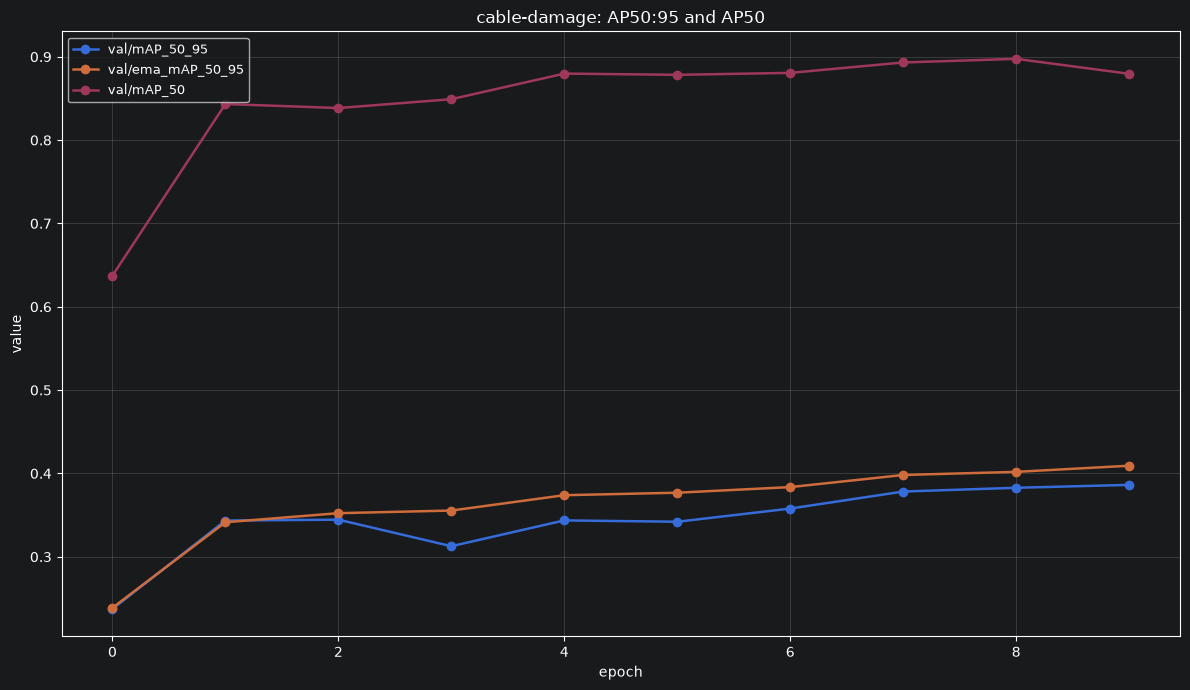

Saved rf100_rfdetr_runs/separate/cable-damage/training_plots/ap50_95_curves.png


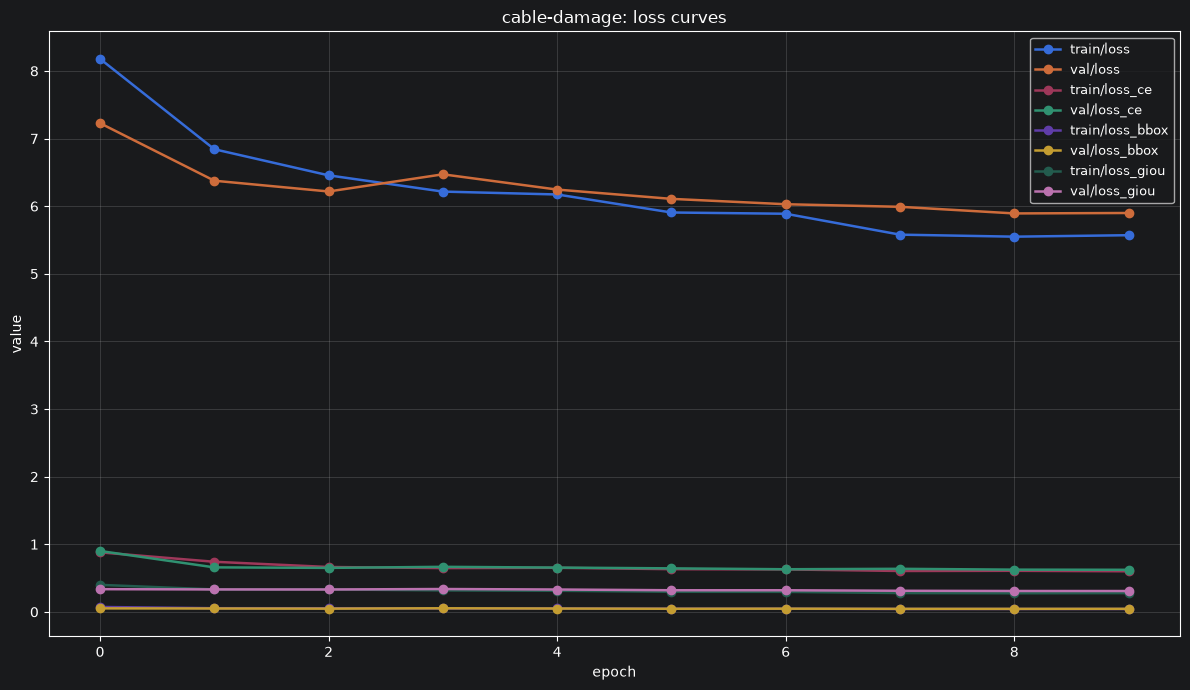

Saved rf100_rfdetr_runs/separate/cable-damage/training_plots/loss_curves.png


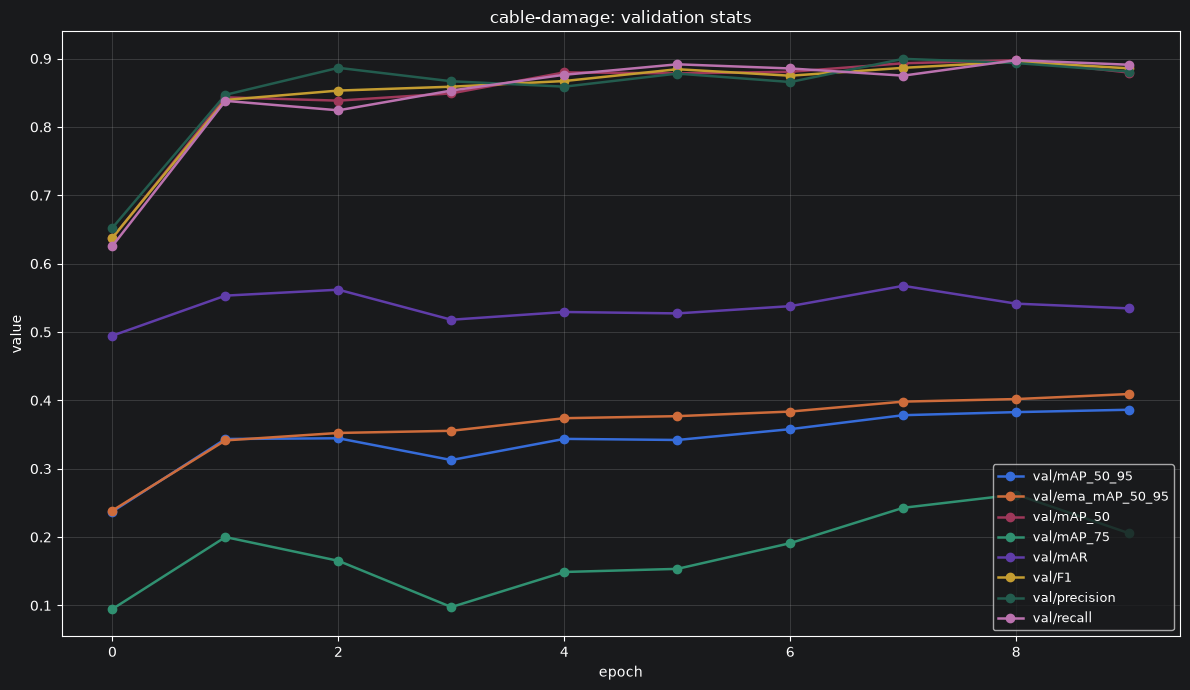

Saved rf100_rfdetr_runs/separate/cable-damage/training_plots/validation_stats.png


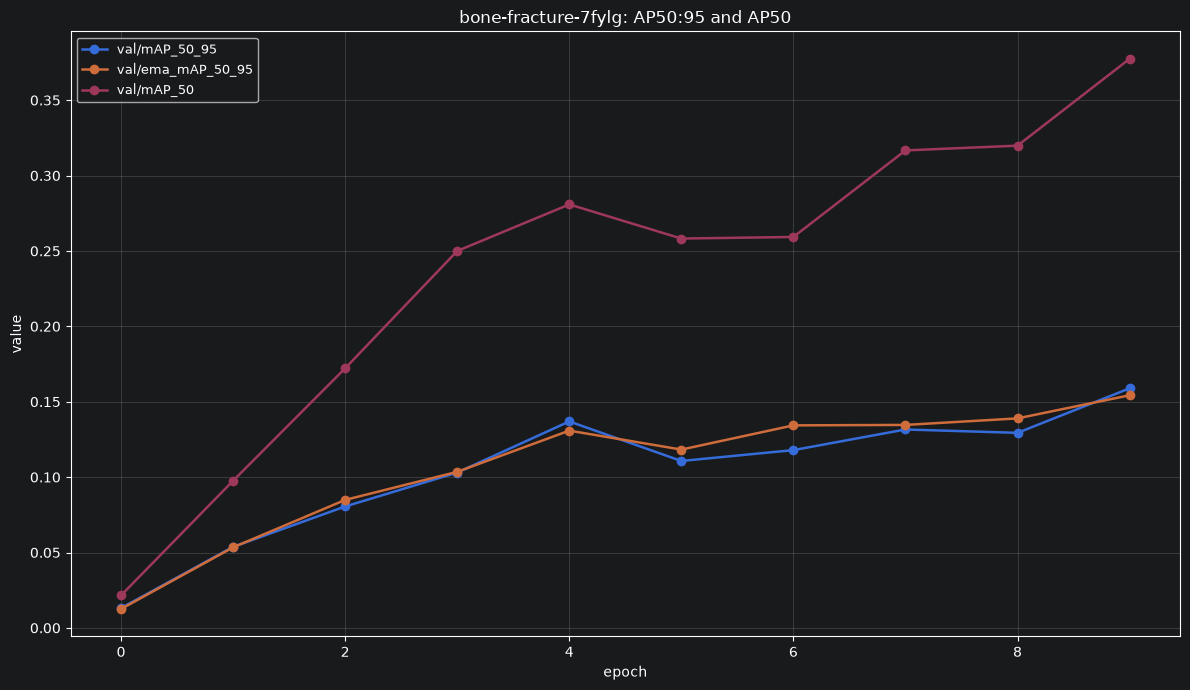

Saved rf100_rfdetr_runs/separate/bone-fracture-7fylg/training_plots/ap50_95_curves.png


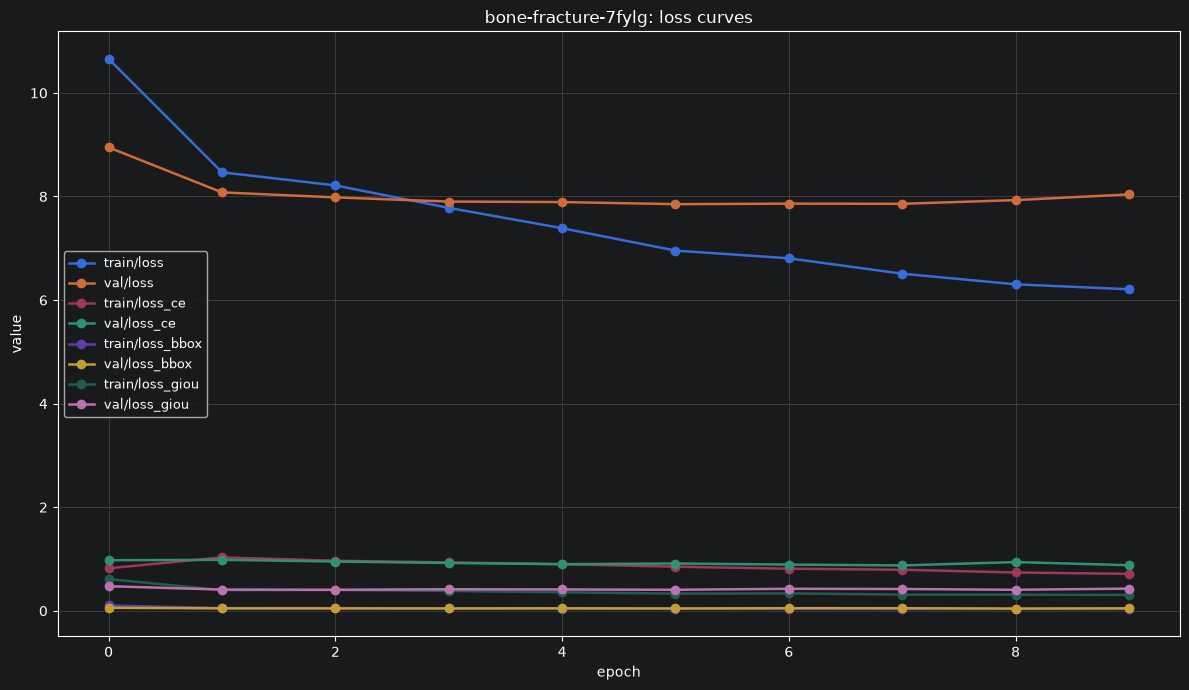

Saved rf100_rfdetr_runs/separate/bone-fracture-7fylg/training_plots/loss_curves.png


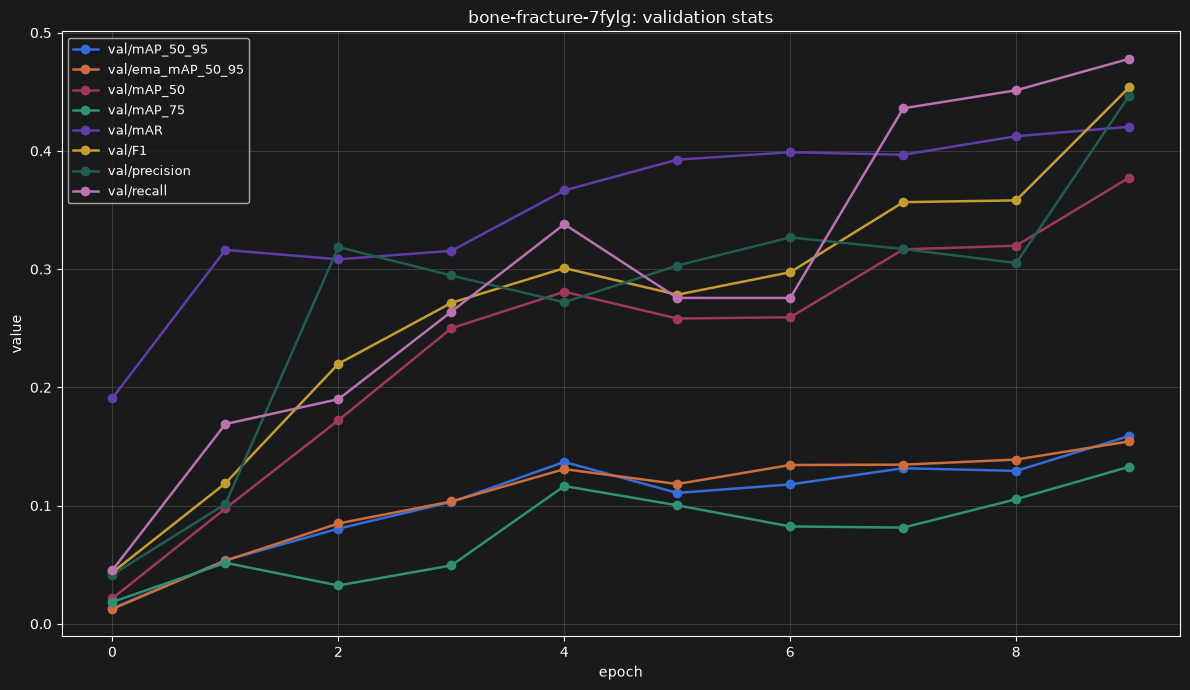

Saved rf100_rfdetr_runs/separate/bone-fracture-7fylg/training_plots/validation_stats.png


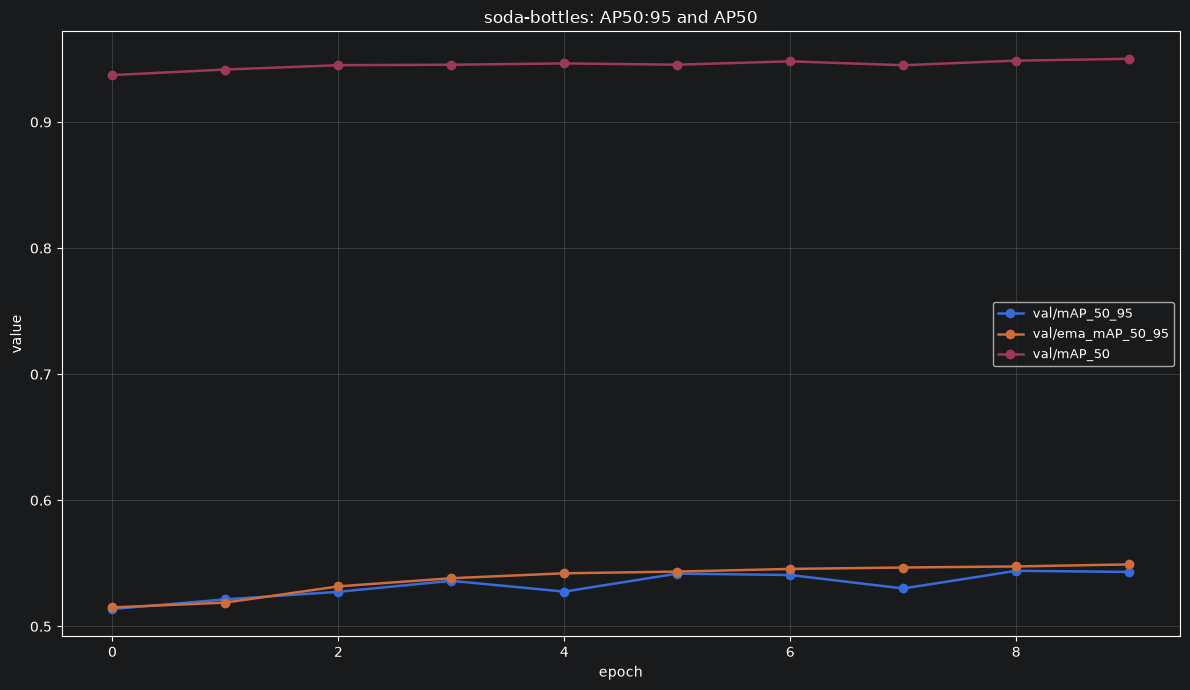

Saved rf100_rfdetr_runs/separate/soda-bottles/training_plots/ap50_95_curves.png


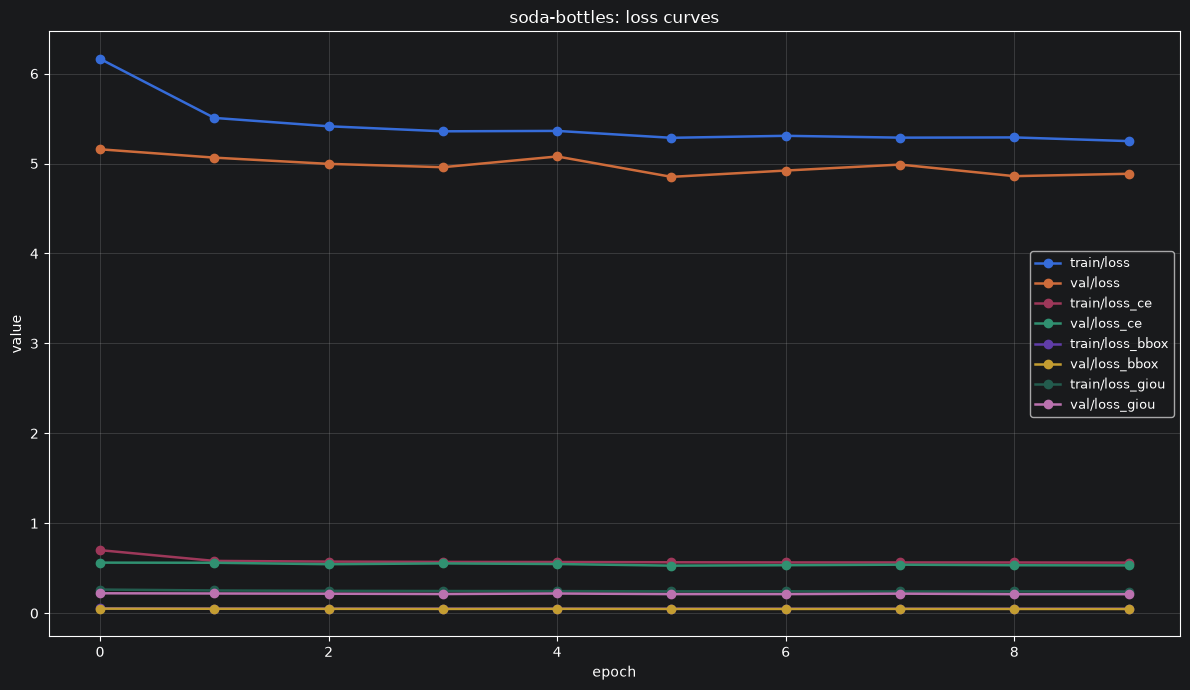

Saved rf100_rfdetr_runs/separate/soda-bottles/training_plots/loss_curves.png


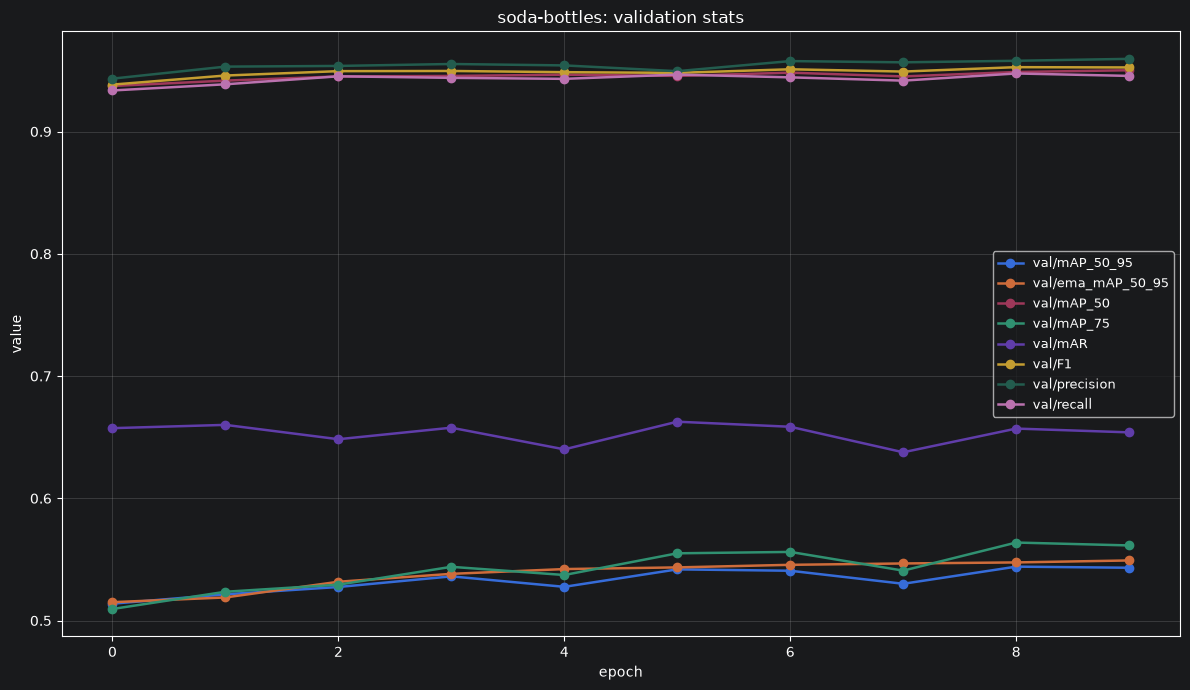

Saved rf100_rfdetr_runs/separate/soda-bottles/training_plots/validation_stats.png


[{'run': 'cable-damage',
  'ap50_95': PosixPath('rf100_rfdetr_runs/separate/cable-damage/training_plots/ap50_95_curves.png'),
  'losses': PosixPath('rf100_rfdetr_runs/separate/cable-damage/training_plots/loss_curves.png'),
  'stats': PosixPath('rf100_rfdetr_runs/separate/cable-damage/training_plots/validation_stats.png')},
 {'run': 'bone-fracture-7fylg',
  'ap50_95': PosixPath('rf100_rfdetr_runs/separate/bone-fracture-7fylg/training_plots/ap50_95_curves.png'),
  'losses': PosixPath('rf100_rfdetr_runs/separate/bone-fracture-7fylg/training_plots/loss_curves.png'),
  'stats': PosixPath('rf100_rfdetr_runs/separate/bone-fracture-7fylg/training_plots/validation_stats.png')},
 {'run': 'soda-bottles',
  'ap50_95': PosixPath('rf100_rfdetr_runs/separate/soda-bottles/training_plots/ap50_95_curves.png'),
  'losses': PosixPath('rf100_rfdetr_runs/separate/soda-bottles/training_plots/loss_curves.png'),
  'stats': PosixPath('rf100_rfdetr_runs/separate/soda-bottles/training_plots/validation_stats.png')

In [17]:
# Plot AP50:95, losses, and validation stats for each current or discovered run.
runs_to_plot = training_runs if "training_runs" in globals() and training_runs else discover_training_run_dirs()

plot_outputs = []
for run in runs_to_plot:
    plot_outputs.append({
        "run": _run_name(run),
        "ap50_95": plot_ap50_95_for_run(run),
        "losses": plot_losses_for_run(run),
        "stats": plot_stats_for_run(run),
    })

plot_outputs

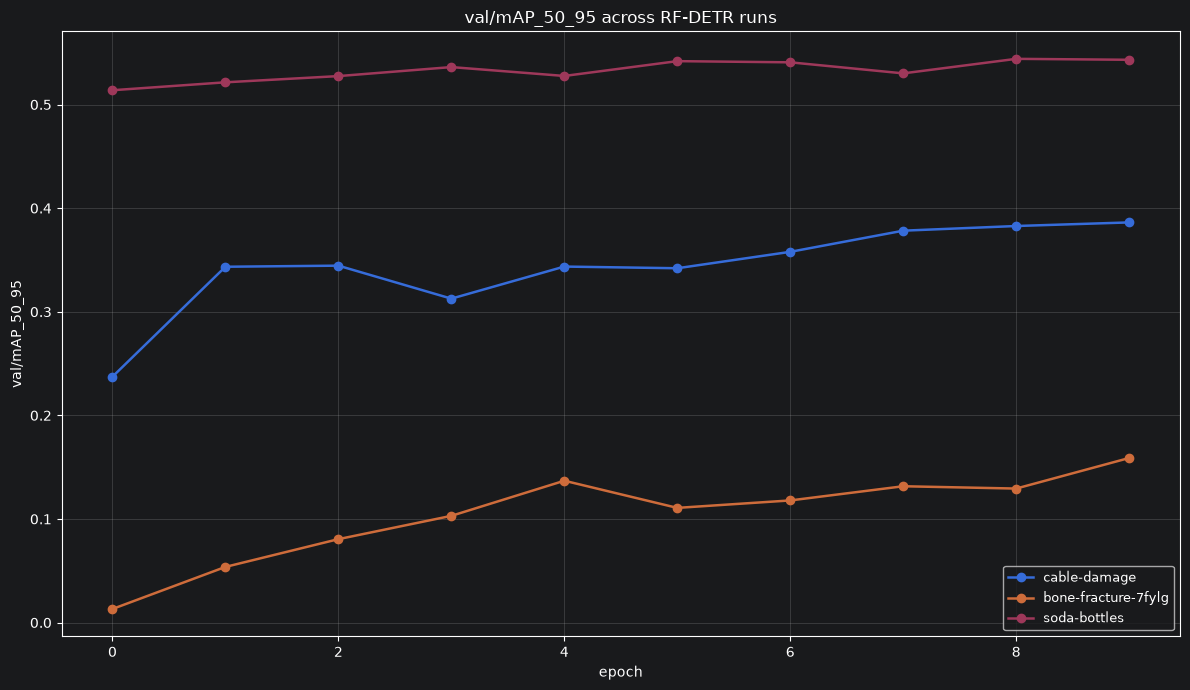

Saved rf100_rfdetr_runs/separate/compare__val_mAP_50_95.png


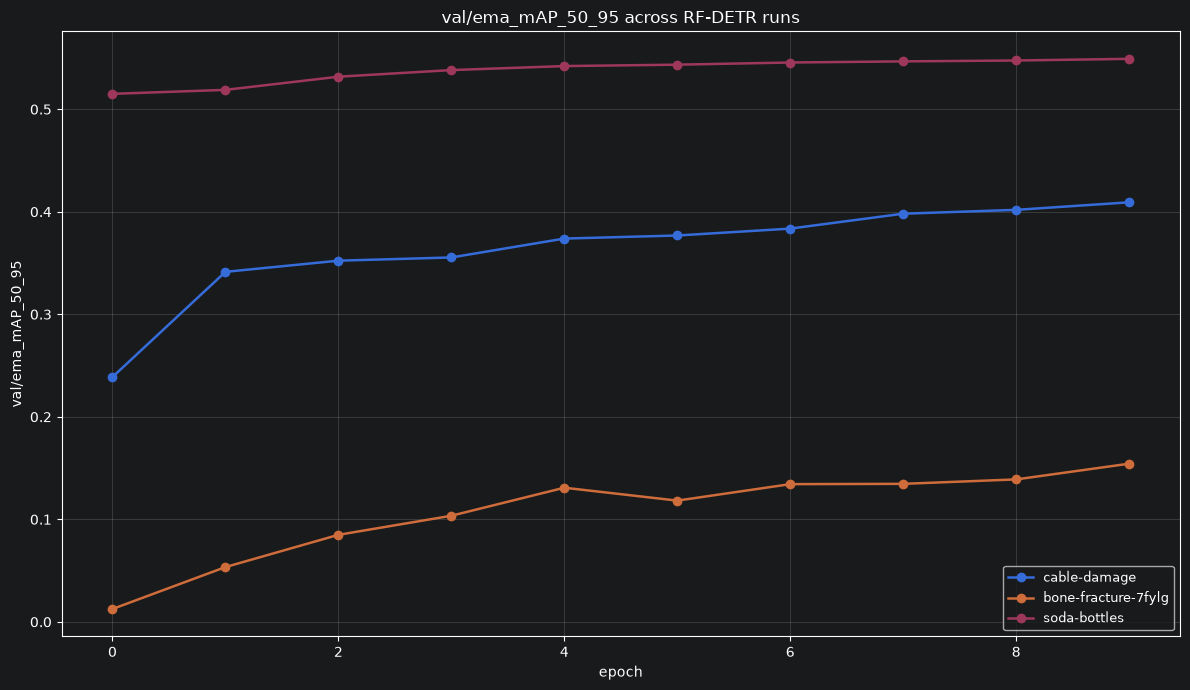

Saved rf100_rfdetr_runs/separate/compare__val_ema_mAP_50_95.png


PosixPath('rf100_rfdetr_runs/separate/compare__val_ema_mAP_50_95.png')

In [16]:
# Compare the main benchmark metric across datasets.
plot_metric_across_runs(AP50_95_METRIC)

# Optional: compare EMA AP50:95 too, when EMA is enabled.
plot_metric_across_runs(EMA_AP50_95_METRIC)

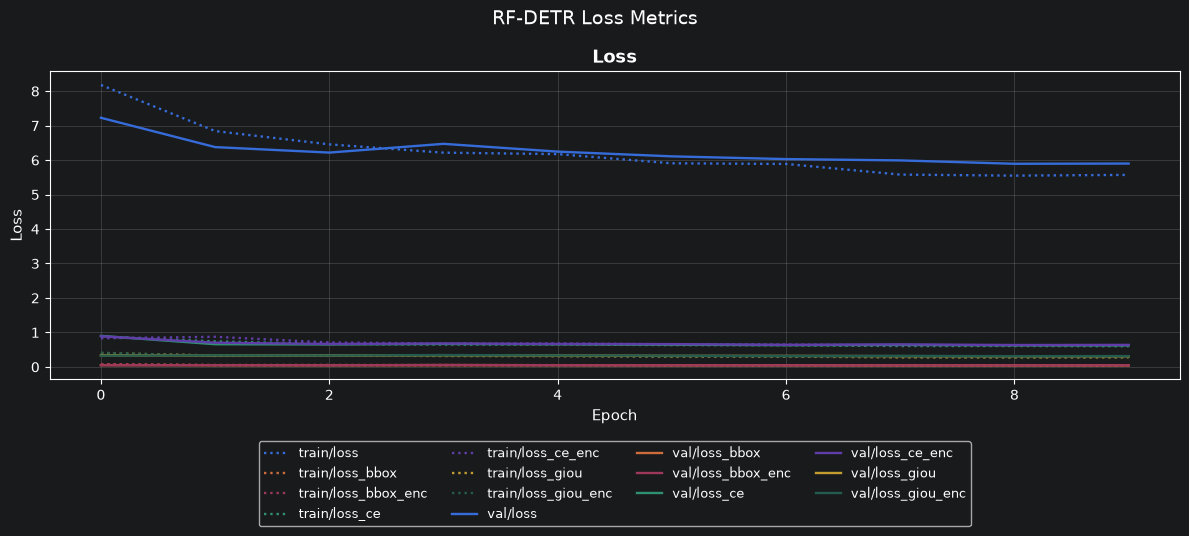

In [18]:
from rfdetr.visualize.training import plot_loss_metrics, plot_map_metrics
from IPython.display import display

loss_figure = plot_loss_metrics(str("/home/arina_belova_jetbrains_com/three_od_models/rf-detr/rf100_rfdetr_runs/separate/cable-damage/metrics.csv"))
display(loss_figure)
plt.close(loss_figure)

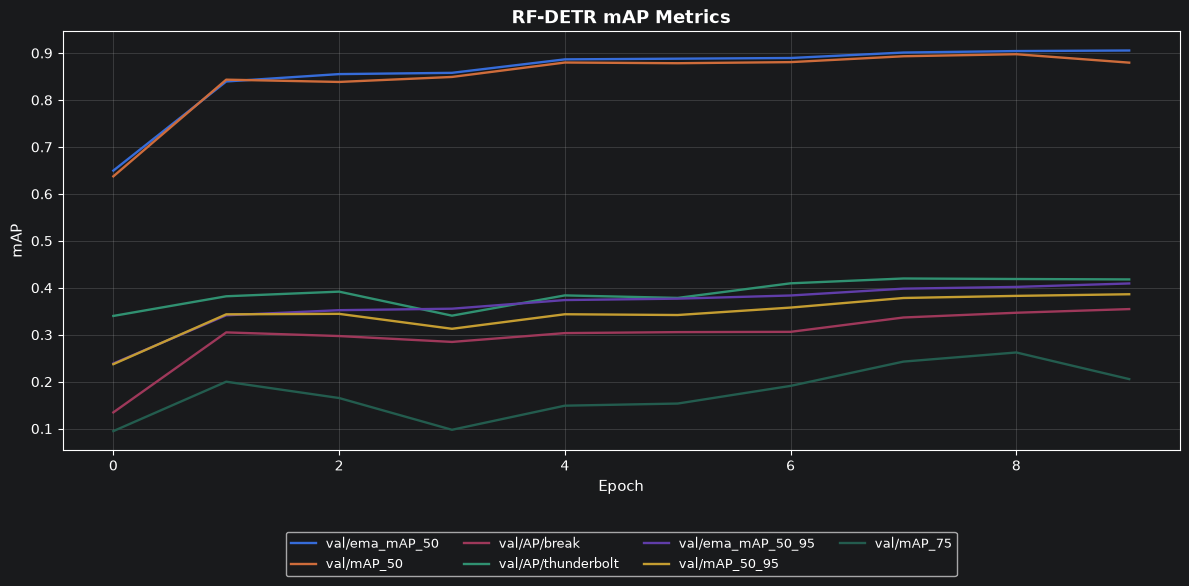

In [19]:
map_figure = plot_map_metrics(str("/home/arina_belova_jetbrains_com/three_od_models/rf-detr/rf100_rfdetr_runs/separate/cable-damage/metrics.csv"))
display(map_figure)
plt.close(map_figure)

## Unified RF100 benchmark: baseline -> fine-tune -> val curve -> test

The cells above explore RF-DETR interactively. For the **cross-model benchmark** shared with YOLOv12 and YOLO26, fine-tuning is packaged in the standalone script **`finetune_rf100.py`** (runs outside Jupyter). Per dataset (`cable-damage`, `bone-fracture-7fylg`, `soda-bottles`) it runs the same four steps and writes `../comparison_results/rfdetr_base_results.json`:

1. **Zero-shot baseline** validation via pycocotools (before fine-tuning)
2. **Fine-tune** for N epochs (default 10; set `--epochs N`) — reuses existing runs with `--skip-existing`
3. **Per-epoch validation curve** (parsed from RF-DETR's `metrics.csv`)
4. **Final `test`-split** stats via pycocotools

**How to run the fine-tune** (from this directory, this venv):

    .venv/bin/python finetune_rf100.py --epochs 10 --skip-existing

The cell below loads the JSON that script produced and shows the baseline vs test table plus the per-dataset validation curves. See `../compare_models.ipynb` for the cross-model comparison.

> **Baseline note:** the COCO-pretrained weights emit COCO class ids, while RF100 reuses those ids for different classes, so zero-shot mAP is ~0. It's the honest "before" reference, not a bug.

In [ ]:
# --- Unified benchmark: run fine-tune OUTSIDE the notebook (recommended) ---
# From this directory, with this venv. --skip-existing reuses the 10-epoch runs
# already under rf100_rfdetr_runs/separate and only (re)computes baseline + test;
# drop it to retrain. Re-run at any depth with --epochs N.
#     .venv/bin/python finetune_rf100.py --epochs 10 --skip-existing
# To launch from inside Jupyter, uncomment:
# !.venv/bin/python finetune_rf100.py --epochs 10 --skip-existing

import json
from pathlib import Path
import matplotlib.pyplot as plt

RESULTS_JSON = Path("../comparison_results/rfdetr_base_results.json")
data = json.loads(RESULTS_JSON.read_text())
print(f"model={data['model']}  epochs={data['epochs']}  imgsz={data['imgsz']}\n")

# Baseline (zero-shot) vs final test per dataset.
for ds, e in data["datasets"].items():
    b, t = e["baseline_val"], e["final_test"]
    print(f"{ds}")
    print(f"  baseline (zero-shot): mAP50={b['mAP50']:.4f}  mAP50-95={b['mAP50_95']:.4f}")
    print(f"  final test          : mAP50={t['mAP50']:.4f}  mAP50-95={t['mAP50_95']:.4f}")

# Validation curve during fine-tuning, one figure per dataset.
for ds, e in data["datasets"].items():
    curve = e.get("val_curve", [])
    if not curve:
        continue
    ep = [c["epoch"] for c in curve]
    plt.figure(figsize=(8, 5))
    for key in ("mAP50", "mAP50_95"):
        plt.plot(ep, [c.get(key) for c in curve], marker="o", label=key)
    plt.title(f"{data['model']} - {ds}: validation metrics vs epoch")
    plt.xlabel("epoch"); plt.ylabel("value"); plt.grid(True, alpha=0.3); plt.legend()
    plt.tight_layout(); plt.show()

## One-shot COCO val2017 check (pretrained, no fine-tune)

Sanity reference: evaluate the **pretrained** RF-DETR-base on **COCO `val2017`** (the 5000-image split it was trained on) with pycocotools. Unlike the RF100 zero-shot baseline (≈0, because RF100 relabels the class ids), this should reproduce roughly RF-DETR's published COCO mAP.

> Uses `val2017`, not `test2017` — COCO's test set has no public labels, so mAP can't be computed on it. Data is prepared once by `../prepare_coco_val.py` (downloads only the val split). Runs inference over all 5000 images (a few minutes on GPU). The result is stored in `../comparison_results/coco_baseline.json`.

In [8]:
# --- One-shot COCO val2017 sanity check (pretrained RF-DETR, NO fine-tune) ---
# RF-DETR has no .val(), so we score with pycocotools over COCO val2017. The
# pretrained model already emits COCO category ids (e.g. dog -> 18), so
# category_id = class_id directly (no +1 shift like the RF100 fine-tuned case).
#
# Speed matters for the benchmark, so we optimize_for_inference() and time each
# predict() (batch=1, CUDA-synced, with warmup). A few COCO val images are
# grayscale/CMYK; RF-DETR.predict() chokes on a raw path for those, so we open
# each image and force .convert("RGB").
#
# Prepare the shared COCO val data once (idempotent, ~1 GB; downloads val2017 only):
#     python3 ../prepare_coco_val.py
# To launch from inside Jupyter, uncomment:
# !python3 ../prepare_coco_val.py

import json, time, statistics
from pathlib import Path
import torch
from PIL import Image
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from rfdetr import RFDETRBase, RFDETRNano, RFDETRLarge

COCO_ROOT = Path.home() / "datasets" / "coco"
ann_path = COCO_ROOT / "annotations" / "instances_val2017.json"
img_dir = COCO_ROOT / "images" / "val2017"

coco_gt = COCO(str(ann_path))
VARIANTS = {"rfdetr_nano": RFDETRNano, "rfdetr_base": RFDETRBase, "rfdetr_large": RFDETRLarge}
model_name = "rfdetr_base"          # pick one
model = VARIANTS[model_name]()       # class derived from the same name — can't drift
model.optimize_for_inference()  # inference-only speed optimization
cuda = torch.cuda.is_available()

images = coco_gt.dataset["images"]

# Warm up so timing excludes one-off trace / autotune costs.
warm = Image.open(img_dir / images[0]["file_name"]).convert("RGB")
for _ in range(3):
    model.predict(warm, threshold=0.05)
if cuda:
    torch.cuda.synchronize()

detections, latencies = [], []
for i, im in enumerate(images):
    image = Image.open(img_dir / im["file_name"]).convert("RGB")
    if cuda:
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    det = model.predict(image, threshold=0.05)
    if cuda:
        torch.cuda.synchronize()
    latencies.append(time.perf_counter() - t0)
    for (x1, y1, x2, y2), conf, cls in zip(det.xyxy, det.confidence, det.class_id):
        detections.append({
            "image_id": im["id"],
            "category_id": int(cls),  # already a COCO category id
            "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
            "score": float(conf),
        })
    if i % 500 == 0:
        print(f"  {i}/{len(images)} images")

coco_dt = coco_gt.loadRes(detections)
ev = COCOeval(coco_gt, coco_dt, "bbox")
ev.evaluate(); ev.accumulate(); ev.summarize()

mean_s = statistics.mean(latencies)
coco = {
    "mAP50": float(ev.stats[1]), "mAP50_95": float(ev.stats[0]), "num_images": len(images),
    "latency_ms_mean": 1000 * mean_s, "latency_ms_median": 1000 * statistics.median(latencies),
    "fps": 1.0 / mean_s, "optimized": True,
}
print(f"{model_name} COCO val2017: mAP50={coco['mAP50']:.4f}  mAP50-95={coco['mAP50_95']:.4f}"
      f"  |  {coco['latency_ms_mean']:.1f} ms/img  ({coco['fps']:.1f} FPS)")

BASE = Path("../comparison_results/coco_baseline.json")
allres = json.loads(BASE.read_text()) if BASE.exists() else {}
allres[f"{model_name}"] = coco
BASE.write_text(json.dumps(allres, indent=2))
print("saved ->", BASE.resolve())

loading annotations into memory...
Done (t=0.52s)
creating index...
index created!


[2026-07-10 12:30:16] [INFO] rf-detr - File /home/arina_belova_jetbrains_com/.roboflow/models/rf-detr-base.pth already exists with correct MD5 hash.
[2026-07-10 12:30:18] [INFO] rf-detr - File /home/arina_belova_jetbrains_com/.roboflow/models/rf-detr-base.pth already exists with correct MD5 hash.


[2026-07-10 12:30:19] [WARNING] rf-detr - Pretrained weights at '/home/arina_belova_jetbrains_com/.roboflow/models/rf-detr-base.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.


  0/5000 images
  500/5000 images
  1000/5000 images
  1500/5000 images
  2000/5000 images
  2500/5000 images
  3000/5000 images
  3500/5000 images
  4000/5000 images
  4500/5000 images
Loading and preparing results...
DONE (t=2.57s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=41.26s).
Accumulating evaluation results...
DONE (t=7.31s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.532
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.721
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.576
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.348
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.584
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.714
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.394
 Average Recall     (AR) @[ IoU=0.50:0.95

## Model size: parameter count

Number of trainable parameters, written to `../comparison_results/model_params.json` so
`compare_models.ipynb` can show it next to the accuracy numbers.

In [10]:
# --- Model size: parameter count ---
import json
from pathlib import Path
from rfdetr import RFDETRBase, RFDETRNano, RFDETRLarge

VARIANTS = {"rfdetr_nano": RFDETRNano, "rfdetr_base": RFDETRBase, "rfdetr_large": RFDETRLarge}
model_name = "rfdetr_large"          # pick one
model = VARIANTS[model_name]()       # class derived from the same name — can't drift
n = sum(p.numel() for p in model.model.model.parameters())
print(f"{model_name}: {n:,} params ({n/1e6:.2f} M)")

B = Path("../comparison_results/model_params.json")
d = json.loads(B.read_text()) if B.exists() else {}
d[f"{model_name}"] = {"num_params": int(n)}
B.write_text(json.dumps(d, indent=2))
print("saved ->", B.resolve())

[2026-07-10 12:42:52] [INFO] rf-detr - File /home/arina_belova_jetbrains_com/.roboflow/models/rf-detr-large-2026.pth already exists with correct MD5 hash.


[2026-07-10 12:42:52] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-10 12:42:52] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-07-10 12:42:53] [INFO] rf-detr - File /home/arina_belova_jetbrains_com/.roboflow/models/rf-detr-large-2026.pth already exists with correct MD5 hash.


[2026-07-10 12:42:53] [WARNING] rf-detr - load_pretrain_weights: checkpoint lacks args.num_queries / args.group_detr; falling back to flat slice. With group_detr=13 this may scramble per-group query structure if the checkpoint was trained with group_detr > 1.
[2026-07-10 12:42:53] [WARNING] rf-detr - Pretrained weights at '/home/arina_belova_jetbrains_com/.roboflow/models/rf-detr-large-2026.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.


rfdetr_large: 33,933,218 params (33.93 M)
saved -> /home/arina_belova_jetbrains_com/three_od_models/comparison_results/model_params.json
